In [ ]:
# Importing Libraries for Data Manipulation
import pandas as pd
import numpy as np
import statsmodels.api as sm
# Importing Libraries for Data Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
import pandas as pd

# Shared style config for visualizations
BLUE      = "#2563EB"
RED       = "#DC2626"
GRAY      = "#6B7280"
LIGHT     = "#F3F4F6"
DARK_TEXT = "#111827"
ACCENT    = "#F59E0B"

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.edgecolor":   "#D1D5DB",
    "grid.color":       "#F3F4F6",
    "font.family":      "DejaVu Sans",
})



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Reading and Loading Data

In [ ]:
# read the data
data = pd.read_csv('/content/drive/MyDrive/Data Mining Project/Motor_Vehicle_Collisions_Crashes.csv')
# returns the first 5 rows
data.head()

/tmp/ipykernel_55768/3553331872.py:2: DtypeWarning: Columns (4,8) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('/content/drive/MyDrive/Data Mining Project/Motor_Vehicle_Collisions_Crashes.csv')


,UNIQUE_ID,COLLISION_ID,CRASH_DATE,CRASH_TIME,VEHICLE_ID,STATE_REGISTRATION,VEHICLE_TYPE,VEHICLE_MAKE,VEHICLE_MODEL,VEHICLE_YEAR,...,VEHICLE_DAMAGE,VEHICLE_DAMAGE_1,VEHICLE_DAMAGE_2,VEHICLE_DAMAGE_3,PUBLIC_PROPERTY_DAMAGE,PUBLIC_PROPERTY_DAMAGE_TYPE,CONTRIBUTING_FACTOR_1,CONTRIBUTING_FACTOR_2,NUMBER OF PERSONS INJURED,NUMBER OF PERSONS KILLED
0,17031445,3405265,3/19/2016,14:21,203530,NJ,4 dr sedan,NISS -CAR/SUV,NaN,2014.0,...,Left Rear Quarter Panel,NaN,NaN,NaN,N,NaN,Unspecified,Unspecified,0,0
1,17031446,3405265,3/19/2016,14:21,203531,NJ,NaN,MITS-TRUCK/BUS,NaN,2010.0,...,Other,NaN,NaN,NaN,N,NaN,NaN,NaN,0,0
2,16937807,3405925,3/22/2016,5:40,161407,NY,NaN,FORD -CAR/SUV,NaN,1997.0,...,Center Front End,NaN,NaN,NaN,N,NaN,Outside Car Distraction,Driver Inattention/Distraction,0,0
3,16945123,3406511,3/22/2016,11:06,32875,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Unspecified,NaN,Passing or Lane Usage Improper,Unspecified,0,0
4,16946723,3406521,3/24/2016,15:30,38027,CT,NaN,BMW -CAR/SUV,NaN,2013.0,...,Left Front Bumper,NaN,NaN,NaN,N,NaN,Unsafe Speed,Following Too Closely,0,0


In [ ]:
# To check number of rows and columns
data.shape

(89102, 27)

In [ ]:
# Checking variables and data types
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89102 entries, 0 to 89101
Data columns (total 27 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   UNIQUE_ID                    89102 non-null  int64  
 1   COLLISION_ID                 89102 non-null  int64  
 2   CRASH_DATE                   89102 non-null  object 
 3   CRASH_TIME                   89102 non-null  object 
 4   VEHICLE_ID                   89102 non-null  object 
 5   STATE_REGISTRATION           85325 non-null  object 
 6   VEHICLE_TYPE                 83229 non-null  object 
 7   VEHICLE_MAKE                 80072 non-null  object 
 8   VEHICLE_MODEL                41 non-null     object 
 9   VEHICLE_YEAR                 80033 non-null  float64
 10  TRAVEL_DIRECTION             85659 non-null  object 
 11  VEHICLE_OCCUPANTS            82667 non-null  float64
 12  DRIVER_SEX                   70537 non-null  object 
 13  DRIVER_LICENSE_S

## Checking for duplicated data

In [ ]:
# Checking for duplicated data
data.duplicated().sum()

np.int64(0)

* No duplicated records were found.

# Data Cleaning and Sanity Checks

In [ ]:
# Converting date and time variables into datetime formats
data['CRASH_DATE'] = pd.to_datetime(data['CRASH_DATE'], errors='coerce')
data['CRASH_HOUR'] = pd.to_datetime(data['CRASH_TIME'], errors='coerce').dt.hour

/tmp/ipykernel_55768/3756320726.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['CRASH_HOUR'] = pd.to_datetime(data['CRASH_TIME'], errors='coerce').dt.hour


In [ ]:
hour_nulls = data["CRASH_HOUR"].isnull().sum()
print(f"Rows with missing CRASH_HOUR (coercion failures): {hour_nulls:,}")


Rows with missing CRASH_HOUR (coercion failures): 0


In [ ]:
# Standardizing variable vehicle make to ensure consistent identification of Ford vehicles
data['VEHICLE_MAKE'] = data['VEHICLE_MAKE'].astype(str).str.upper().str.strip()

In [ ]:
data['NUMBER OF PERSONS KILLED'] = pd.to_numeric(
    data['NUMBER OF PERSONS KILLED'], errors='coerce'
)
#make this column into usable numbers. If it contains values other than numbers, it
#will turn it into NaN

# Handling Missing Values

In [ ]:
# Removing unnecessary columns
data = data.drop(['STATE_REGISTRATION',
                  'VEHICLE_MODEL',
                  'VEHICLE_ID',
                  'PUBLIC_PROPERTY_DAMAGE',
                  'PUBLIC_PROPERTY_DAMAGE_TYPE',
                  'DRIVER_LICENSE_JURISDICTION',
                  'UNIQUE_ID',
                  'VEHICLE_DAMAGE',
                  'VEHICLE_DAMAGE_1',
                  'VEHICLE_DAMAGE_2',
                  'VEHICLE_DAMAGE_3'], axis=1)

In [ ]:
 # Dropping empty rows
data = data.dropna(subset=['VEHICLE_MAKE', 'NUMBER OF PERSONS KILLED','DRIVER_SEX',
                           'CRASH_DATE', 'VEHICLE_YEAR'])

# Feature Engineering

In [ ]:
data['IS_FORD'] = data['VEHICLE_MAKE'].str.contains('FORD', na=False).astype(int)
#checks the column to make ford = true, and others into false.
#and then turning true to 1 and others to 0

In [ ]:
data['DEATH'] = (data['NUMBER OF PERSONS KILLED'] > 0).astype(int)
#same thing but for death

In [ ]:
data['DEATH'].value_counts(normalize=True)

,proportion
DEATH,
0,0.999447
1,0.000553




**Limitation:**
Death is rare which affects model stability. Fatal events are rare, which may limit statistical power.

In [ ]:
# Creating a binary variable to identify whether driver is Male or Female
data['IS_MALE'] = (data['DRIVER_SEX'] == 'M').astype(int)

In [ ]:
data[(data['DRIVER_SEX'] == 'U') & (data['IS_FORD'] == 1)].shape[0]

34

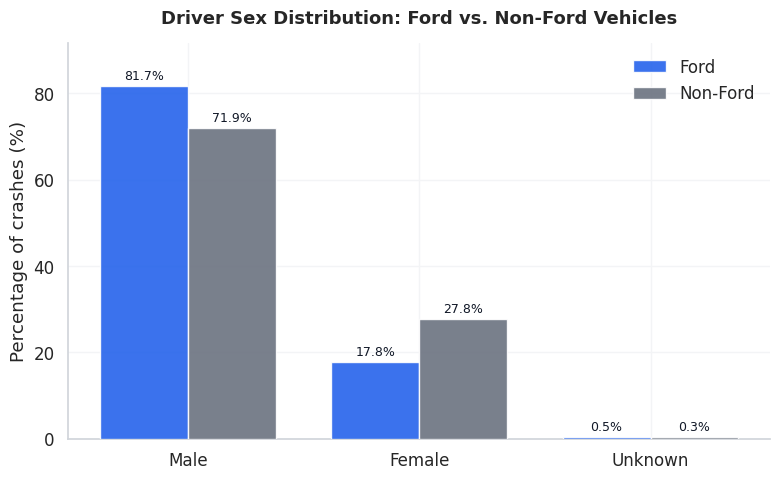

In [ ]:
def plot_driver_sex_proportions(data):
    sex_map    = {"M": "Male", "F": "Female", "U": "Unknown"}
    ford       = data[data["IS_FORD"] == 1]["DRIVER_SEX"].map(sex_map).value_counts(normalize=True) * 100
    non_ford   = data[data["IS_FORD"] == 0]["DRIVER_SEX"].map(sex_map).value_counts(normalize=True) * 100

    categories = ["Male", "Female", "Unknown"]
    ford_vals     = [ford.get(c, 0)     for c in categories]
    non_ford_vals = [non_ford.get(c, 0) for c in categories]

    x     = np.arange(len(categories))
    width = 0.38

    fig, ax = plt.subplots(figsize=(8, 5))
    bars1 = ax.bar(x - width/2, ford_vals,     width, label="Ford",     color=BLUE,  alpha=0.9, zorder=3)
    bars2 = ax.bar(x + width/2, non_ford_vals, width, label="Non-Ford", color=GRAY,  alpha=0.9, zorder=3)

    for bar in list(bars1) + list(bars2):
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.8, f"{h:.1f}%",
                ha="center", va="bottom", fontsize=9, color=DARK_TEXT)

    ax.set_xticks(x)
    ax.set_xticklabels(categories)
    ax.set_ylabel("Percentage of crashes (%)")
    ax.set_title("Driver Sex Distribution: Ford vs. Non-Ford Vehicles",
                 fontsize=13, fontweight="bold", pad=14)
    ax.legend(frameon=False)
    ax.set_ylim(0, max(ford_vals + non_ford_vals) + 10)
    ax.yaxis.grid(True, zorder=0)
    plt.tight_layout()
    plt.show()

plot_driver_sex_proportions(data)

In [ ]:
# Identify most common contributing factors and decide which variables to create
pd.concat([data['CONTRIBUTING_FACTOR_1'], data['CONTRIBUTING_FACTOR_2']]).value_counts()

,count
Unspecified,89053
Driver Inattention/Distraction,14691
Following Too Closely,6074
Failure to Yield Right-of-Way,4121
Unsafe Lane Changing,2718
Passing or Lane Usage Improper,2652
Other Vehicular,2395
Backing Unsafely,2097
Passing Too Closely,2056
Turning Improperly,1643


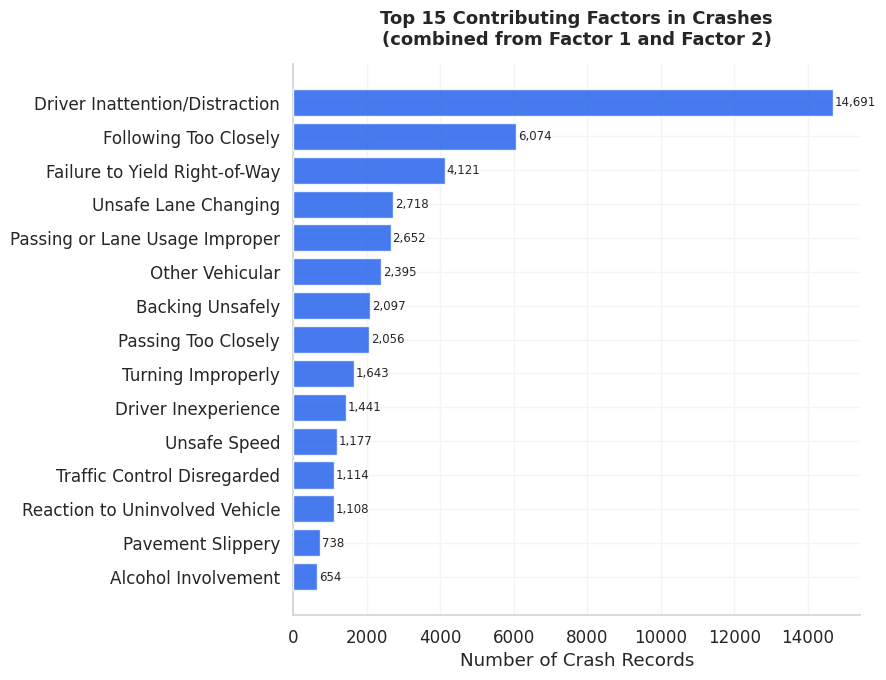

In [ ]:
def plot_contributing_factors(data):
    factor_counts = (
        pd.concat([data["CONTRIBUTING_FACTOR_1"], data["CONTRIBUTING_FACTOR_2"]])
          .value_counts()
          .drop("Unspecified", errors="ignore")
          .head(15)
    )

    fig, ax = plt.subplots(figsize=(9, 7))
    bars = ax.barh(factor_counts.index[::-1], factor_counts.values[::-1],
                   color=BLUE, alpha=0.85, edgecolor="white", zorder=3)

    for bar in bars:
        w = bar.get_width()
        ax.text(w + 50, bar.get_y() + bar.get_height() / 2, f"{int(w):,}",
                va="center", fontsize=8.5)

    ax.set_xlabel("Number of Crash Records")
    ax.set_title("Top 15 Contributing Factors in Crashes\n(combined from Factor 1 and Factor 2)",
                 fontsize=13, fontweight="bold", pad=14)
    ax.xaxis.grid(True, zorder=0)
    ax.set_axisbelow(True)
    plt.tight_layout()
    plt.show()

plot_contributing_factors(data)


In [ ]:
# Creating a binary variable to identify if speeding was present as a contributing factor in the crash
data['SPEEDING'] = (
    (data['CONTRIBUTING_FACTOR_1'] == 'Unsafe Speed') |
    (data['CONTRIBUTING_FACTOR_2'] == 'Unsafe Speed')
).astype(int)

In [ ]:
# Creating a binary variable to identify if Alcohol was present as a contributing factor in the crash
data['ALCOHOL'] = (
    (data['CONTRIBUTING_FACTOR_1'] == 'Alcohol Involvement') |
    (data['CONTRIBUTING_FACTOR_2'] == 'Alcohol Involvement')
).astype(int)

In [ ]:
# Creating a binary variable to identify if Distraction was present as a contributing factor in the crash
data['DISTRACTION'] = (
    (data['CONTRIBUTING_FACTOR_1'] == 'Driver Inattention/Distraction') |
    (data['CONTRIBUTING_FACTOR_2'] == 'Driver Inattention/Distraction')
).astype(int)

In [ ]:
# Creating a binary variable to identify if Pedestrians was present as a contributing factor in the crash
data['PEDESTRIANS_INVOLVED'] = (
    (data['CONTRIBUTING_FACTOR_1'] == 'Pedestrian/Bicyclist/Other Pedestrian Error/Confusion') |
    (data['CONTRIBUTING_FACTOR_2'] == 'Pedestrian/Bicyclist/Other Pedestrian Error/Confusion')
).astype(int)

In [ ]:
# Creating a binary variable to identify if Pedestrians was present as a contributing factor in the crash
data['AGGRESIVE_DRIVING'] = (
    (data['CONTRIBUTING_FACTOR_1'] == 'Aggressive Driving/Road Rage') |
    (data['CONTRIBUTING_FACTOR_2'] == 'Aggressive Driving/Road Rage')
).astype(int)

In [ ]:
# Creating a binary variable to identify if Pedestrians was present as a contributing factor in the crash
data['FOLLOWING_TOO_CLOSE'] = (
    (data['CONTRIBUTING_FACTOR_1'] == 'Following Too Closely') |
    (data['CONTRIBUTING_FACTOR_2'] == 'Following Too Closely')
).astype(int)

In [ ]:
# Creating variable to check if there more than 1 vehicle involved in the crash
data['NUMBER_OF_VEHICLES'] = data.groupby('COLLISION_ID')['COLLISION_ID'].transform('count')

In [ ]:
data['MULTI_VEHICLE'] = (data['NUMBER_OF_VEHICLES'] > 1).astype(int)

In [ ]:
# Retrieving year of the crash to calculate vehicle year
data['CRASH_YEAR'] = data['CRASH_DATE'].dt.year

In [ ]:
# Including only Vehicles bwtween 1900 to 2024 leaving out unrealistic values
data = data[(data['VEHICLE_YEAR'] >= 1900) & (data['VEHICLE_YEAR'] <= 2024)]

* MAYBE A CHART OF VEHICLE YEARS

In [ ]:
# Calculating Vehicle Age
data['VEHICLE_AGE'] = data['CRASH_YEAR'] - data['VEHICLE_YEAR']
data = data[data['VEHICLE_AGE'] >= 0]

In [ ]:
data['VEHICLE_AGE'].describe()

,VEHICLE_AGE
count,67451.000000
mean,6.098946
std,5.515095
min,0.000000
25%,1.000000
50%,4.000000
75%,10.000000
max,80.000000


In [ ]:
data[data['VEHICLE_AGE'] < 0][
    ['CRASH_DATE', 'CRASH_YEAR', 'VEHICLE_YEAR', 'VEHICLE_AGE']
]

,CRASH_DATE,CRASH_YEAR,VEHICLE_YEAR,VEHICLE_AGE


In [ ]:
# Definig variable whether crash happened at day or night. Where 1 (crash happened at night) or 0 (crash happened during the day)
data['NIGHT_CRASH'] = data['CRASH_HOUR'].apply(
    lambda x: 1 if (x >= 20 or x < 6) else 0
)
data['NIGHT_CRASH'].value_counts()

,count
NIGHT_CRASH,
0,52236
1,15215


In [ ]:
# Definig whether crash happened during rush hour 1 or  not rush hour 0
data['RUSH_HOUR'] = data['CRASH_HOUR'].apply(
    lambda x: 1 if ((7 <= x < 10) or (16 <= x < 19)) else 0
)
data['RUSH_HOUR'].value_counts()

,count
RUSH_HOUR,
0,43257
1,24194


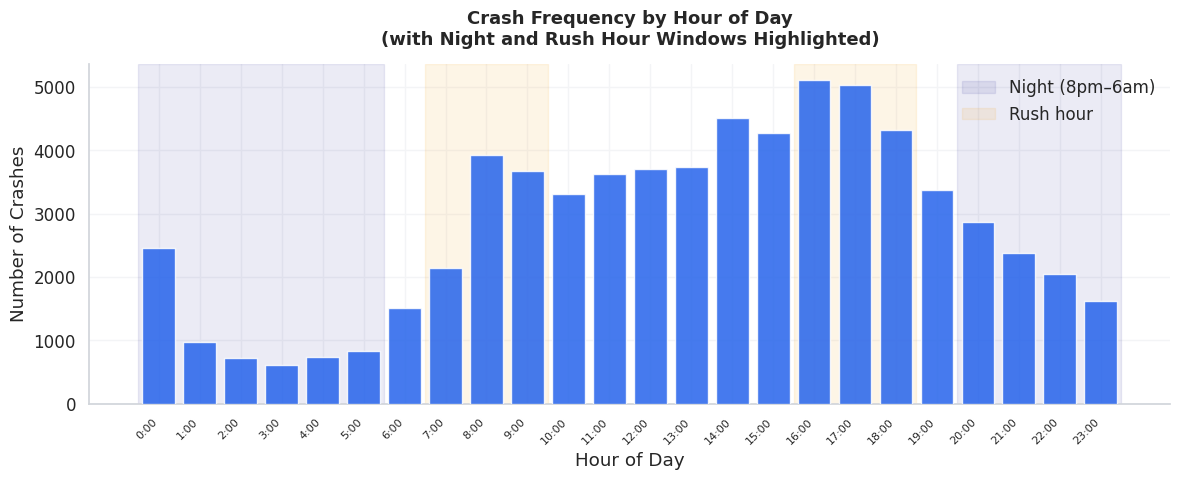

In [ ]:
def plot_crashes_by_hour(data):
    hourly = data["CRASH_HOUR"].value_counts().sort_index()

    fig, ax = plt.subplots(figsize=(12, 5))

    # Shade night hours (20–23 and 0–5)
    ax.axvspan(-0.5, 5.5,  alpha=0.08, color="navy",  label="Night (8pm–6am)")
    ax.axvspan(19.5, 23.5, alpha=0.08, color="navy")

    # Shade rush hours
    ax.axvspan(6.5,  9.5,  alpha=0.10, color=ACCENT, label="Rush hour")
    ax.axvspan(15.5, 18.5, alpha=0.10, color=ACCENT)

    ax.bar(hourly.index, hourly.values, color=BLUE, alpha=0.85, edgecolor="white", zorder=3)

    ax.set_xticks(range(0, 24))
    ax.set_xticklabels([f"{h}:00" for h in range(24)], rotation=45, ha="right", fontsize=8)
    ax.set_xlabel("Hour of Day")
    ax.set_ylabel("Number of Crashes")
    ax.set_title("Crash Frequency by Hour of Day\n(with Night and Rush Hour Windows Highlighted)",
                 fontsize=13, fontweight="bold", pad=14)
    ax.legend(frameon=False)
    ax.yaxis.grid(True, zorder=0)
    plt.tight_layout()
    plt.show()

plot_crashes_by_hour(data)

In [ ]:
# Definig whether crash happened on weekend = 1 or weekdays = 0
data['WEEKEND'] = data['CRASH_DATE'].dt.dayofweek.apply(
    lambda x: 1 if x >= 5 else 0
)
data['WEEKEND'].value_counts()

,count
WEEKEND,
0,50914
1,16537


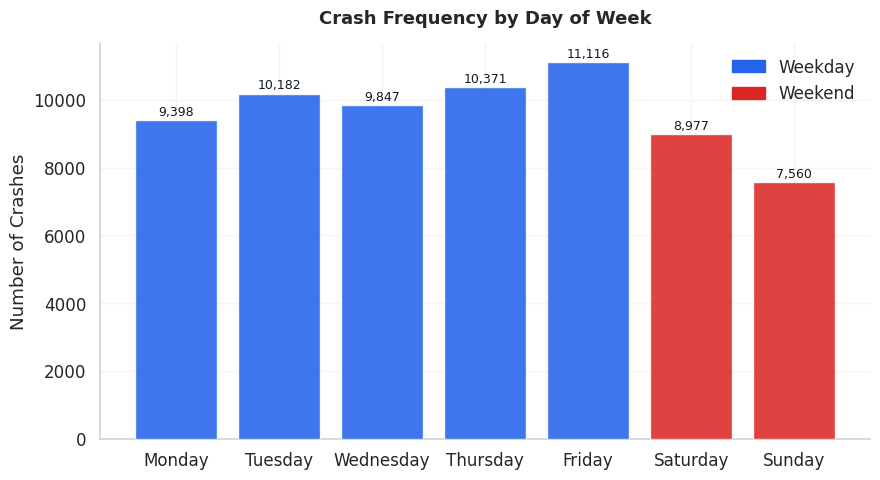

In [ ]:
def plot_crashes_by_day(data):
    day_order  = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
    day_names  = data["CRASH_DATE"].dt.day_name()
    day_counts = day_names.value_counts().reindex(day_order)
    colors     = [RED if d in ["Saturday", "Sunday"] else BLUE for d in day_order]

    fig, ax = plt.subplots(figsize=(9, 5))
    bars = ax.bar(day_order, day_counts.values, color=colors, alpha=0.88, edgecolor="white", zorder=3)

    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 50, f"{int(h):,}",
                ha="center", va="bottom", fontsize=9, color=DARK_TEXT)

    weekday_patch = mpatches.Patch(color=BLUE, label="Weekday")
    weekend_patch = mpatches.Patch(color=RED,  label="Weekend")
    ax.legend(handles=[weekday_patch, weekend_patch], frameon=False)

    ax.set_ylabel("Number of Crashes")
    ax.set_title("Crash Frequency by Day of Week",
                 fontsize=13, fontweight="bold", pad=14)
    ax.yaxis.grid(True, zorder=0)
    plt.tight_layout()
    plt.show()

plot_crashes_by_day(data)

In [ ]:
#data['IS_FORD'].value_counts() #double check how many fords are in the list
#data['DEATH'].value_counts() #double check how many deaths are in the list

In [ ]:
# Creating function using month of the crash to get the season
data['MONTH'] = data['CRASH_DATE'].dt.month
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

data['SEASON'] = data['MONTH'].apply(get_season)
data[['CRASH_DATE', 'MONTH', 'SEASON']].head()

,CRASH_DATE,MONTH,SEASON
0,2016-03-19,3,Spring
2,2016-03-22,3,Spring
4,2016-03-24,3,Spring
5,2016-03-24,3,Spring
6,2016-03-25,3,Spring


/tmp/ipykernel_55768/3550071536.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(loc="upper right", frameon=False)


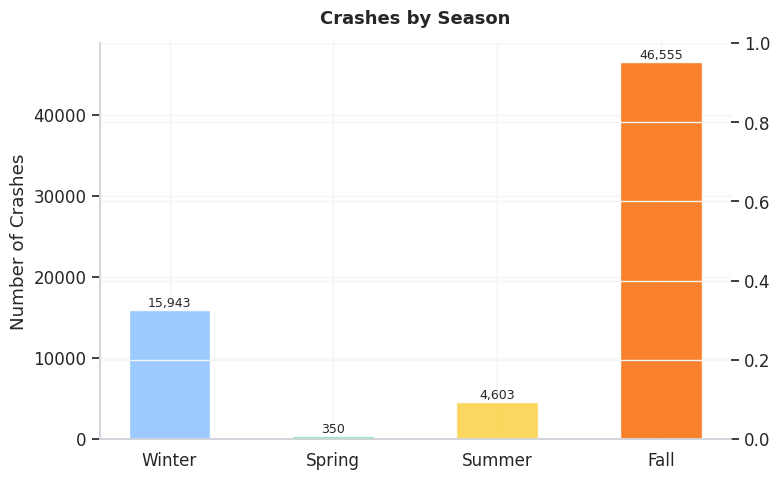

In [ ]:
def plot_crashes_by_season(data):
    season_order  = ["Winter", "Spring", "Summer", "Fall"]
    season_counts = data.groupby("SEASON").agg(
        total_crashes=("DEATH", "count"),
        fatal_rate=("DEATH", "mean")
    ).reindex(season_order)

    season_colors = {"Winter": "#93C5FD", "Spring": "#6EE7B7",
                     "Summer": "#FCD34D", "Fall":   "#F97316"}
    bar_colors = [season_colors[s] for s in season_order]

    fig, ax1 = plt.subplots(figsize=(8, 5))
    ax2 = ax1.twinx()

    bars = ax1.bar(season_order, season_counts["total_crashes"],
                   color=bar_colors, alpha=0.9, edgecolor="white", zorder=3, width=0.5)


    for bar in bars:
        h = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width() / 2, h + 30, f"{int(h):,}",
                 ha="center", va="bottom", fontsize=9)

    ax1.set_ylabel("Number of Crashes")
    ax1.set_title("Crashes by Season",
                  fontsize=13, fontweight="bold", pad=14)
    ax1.yaxis.grid(True, zorder=0)
    ax2.legend(loc="upper right", frameon=False)
    plt.tight_layout()
    plt.show()

plot_crashes_by_season(data)

In [ ]:
data['CRASH_DATE'].dt.month.value_counts().sort_index()

,count
CRASH_DATE,
1,939
2,8
3,42
4,70
5,238
8,4603
9,14270
10,16338
11,15947


In [ ]:
data.groupby(data['CRASH_DATE'].dt.month)['DEATH'].sum().sort_index()

,DEATH
CRASH_DATE,
1,1
2,0
3,1
4,1
5,0
8,2
9,8
10,8
11,8


In [ ]:
data['CRASH_DATE'].dt.month.value_counts().sort_index().reindex(range(1,13), fill_value=0)

,count
CRASH_DATE,
1,939
2,8
3,42
4,70
5,238
6,0
7,0
8,4603
9,14270


In [ ]:
data[(data['IS_FORD'] == 1) & (data['DEATH'] == 1)].shape[0] #when death occured in ford

8

In [ ]:
# Making variable for 3 types of vehicles
def simplify_vehicle_type(x):
    x = str(x).upper()

    if 'SEDAN' in x:
        return 'Sedan'
    elif 'SPORT UTILITY' in x or 'SUV' in x or 'STATION WAGON' in x:
        return 'SUV'
    elif 'PICK-UP' in x or 'PICKUP' in x:
        return 'Pick-up Truck'
    else:
        return 'Other'

data['VEHICLE_TYPES'] = data['VEHICLE_TYPE'].apply(simplify_vehicle_type)


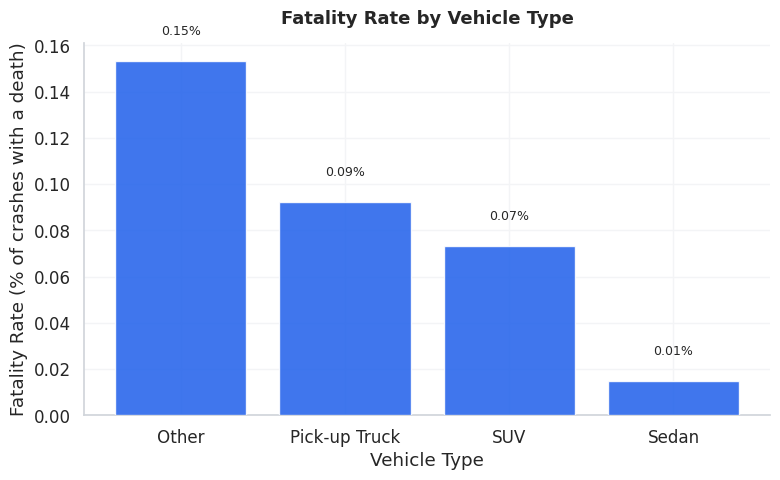

In [ ]:
def plot_fatality_by_vehicle_type(data):
    vtype_stats = (
        data.groupby("VEHICLE_TYPES")
            .agg(total=("DEATH", "count"), fatal_rate=("DEATH", "mean"))
            .sort_values("fatal_rate", ascending=False)
    )
    vtype_stats["fatal_rate_pct"] = vtype_stats["fatal_rate"] * 100

    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(vtype_stats.index, vtype_stats["fatal_rate_pct"],
                  color=BLUE, alpha=0.88, edgecolor="white", zorder=3)

    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.01, f"{h:.2f}%",
                ha="center", va="bottom", fontsize=9)

    ax.set_ylabel("Fatality Rate (% of crashes with a death)")
    ax.set_xlabel("Vehicle Type")
    ax.set_title("Fatality Rate by Vehicle Type",
                 fontsize=13, fontweight="bold", pad=14)
    ax.yaxis.grid(True, zorder=0)
    plt.tight_layout()
    plt.show()

plot_fatality_by_vehicle_type(data)


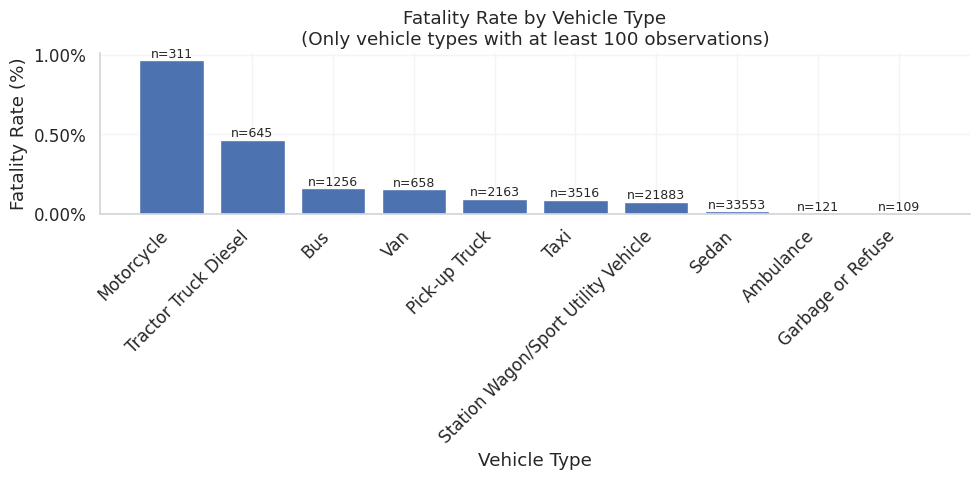

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Create summary table
vehicle_summary = data.groupby('VEHICLE_TYPE').agg(
    fatality_rate=('DEATH', 'mean'),
    deaths=('DEATH', 'sum'),
    observations=('DEATH', 'count')
).reset_index()

# Keep only vehicle types with enough observations
vehicle_summary = vehicle_summary[vehicle_summary['observations'] >= 100]

# Sort by fatality rate
vehicle_summary = vehicle_summary.sort_values('fatality_rate', ascending=False).head(10)

# Plot
plt.figure(figsize=(10,5))
plt.bar(vehicle_summary['VEHICLE_TYPE'], vehicle_summary['fatality_rate'])

plt.title("Fatality Rate by Vehicle Type\n(Only vehicle types with at least 100 observations)")
plt.xlabel("Vehicle Type")
plt.ylabel("Fatality Rate (%)")
plt.xticks(rotation=45, ha='right')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# Add sample size labels
for i, row in enumerate(vehicle_summary.itertuples()):
    plt.text(
        i,
        row.fatality_rate,
        f"n={row.observations}",
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [ ]:
#data['VEHICLE_OCCUPANTS'] = pd.to_numeric(data['VEHICLE_OCCUPANTS'], errors='coerce')
#data['VEHICLE_OCCUPANTS'].describe()
# data = data[
#     (data['VEHICLE_OCCUPANTS'] >= 1) &
#     (data['VEHICLE_OCCUPANTS'] <= 15)
# ] Removing unrealistic number of occuapnts like 413

In [ ]:
# Creating a variable to check driver's license status when the crash ocurred
data['UNLICENSED'] = (
    data['DRIVER_LICENSE_STATUS']
    .str.contains('Unlicensed|Suspended|Revoked', case=False, na=False)
).astype(int)
#data['UNLICENSED'].value_counts()

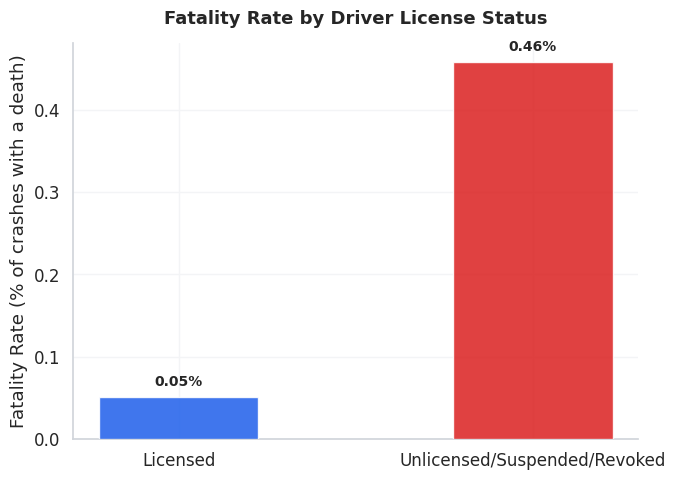

In [ ]:
def plot_fatality_by_license_status(data):
    lic_stats = (
        data.groupby("UNLICENSED")["DEATH"]
            .agg(["count", "mean"])
            .rename(index={0: "Licensed", 1: "Unlicensed/Suspended/Revoked"})
    )
    lic_stats["fatal_rate_pct"] = lic_stats["mean"] * 100

    fig, ax = plt.subplots(figsize=(7, 5))
    colors = [BLUE, RED]
    bars = ax.bar(lic_stats.index, lic_stats["fatal_rate_pct"],
                  color=colors, alpha=0.88, edgecolor="white", width=0.45, zorder=3)

    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.01, f"{h:.2f}%",
                ha="center", va="bottom", fontsize=10, fontweight="bold")

    ax.set_ylabel("Fatality Rate (% of crashes with a death)")
    ax.set_title("Fatality Rate by Driver License Status",
                 fontsize=13, fontweight="bold", pad=14)
    ax.yaxis.grid(True, zorder=0)
    plt.tight_layout()
    plt.show()

plot_fatality_by_license_status(data)

In [ ]:
# Creating a binary variable to identify whether a given observation is associated with a crash involving a Front Point of Impact
data['FRONT_IMPACT'] = (
    data['POINT_OF_IMPACT']
    .astype(str)
    .str.contains('Front', case=False, na=False)
).astype(int)


In [ ]:
# Creating a binary variable to identify whether a given observation is associated with a crash involving a
data['GOING_STRAIGHT'] = data['PRE_CRASH'].str.contains(
    'Going Straight', case=False, na=False
).astype(int)

In [ ]:
data['PRE_CRASH'].unique()

array(['Parked', 'Going Straight Ahead', 'Stopped in Traffic', 'Passing',
       'Changing Lanes', 'Other*', 'Making Right Turn',
       'Starting from Parking', 'Making Left Turn', 'Backing',
       'Slowing or Stopping', 'Entering Parked Position', 'Merging',
       'Making U Turn', 'Avoiding Object in Roadway', nan,
       'Starting in Traffic', 'Making Left Turn on Red',
       'Making Right Turn on Red', 'Police Pursuit'], dtype=object)

# Running Simple Logistic Regression Model

In [ ]:
X = data[['IS_FORD']]
X = sm.add_constant(X)   # intercept

y = data['DEATH']

logit_model = sm.Logit(y, X)
result = logit_model.fit()

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.004750
         Iterations 12
                           Logit Regression Results                           
Dep. Variable:                  DEATH   No. Observations:                67451
Model:                          Logit   Df Residuals:                    67449
Method:                           MLE   Df Model:                            1
Date:                Thu, 07 May 2026   Pseudo R-squ.:                0.005879
Time:                        01:52:55   Log-Likelihood:                -320.39
converged:                       True   LL-Null:                       -322.29
Covariance Type:            nonrobust   LLR p-value:                   0.05158
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -7.6089      0.183    -41.665      0.000      -7.967      -7.251
IS_FORD        0.8444      0

# Running Multiple Logistic Regression Model

In [ ]:
X = data[['IS_FORD','IS_MALE','SPEEDING','DISTRACTION', 'NIGHT_CRASH','RUSH_HOUR', 'SEASON'
,'VEHICLE_TYPES', 'UNLICENSED', 'FRONT_IMPACT','GOING_STRAIGHT', 'VEHICLE_AGE', 'FOLLOWING_TOO_CLOSE','MULTI_VEHICLE']]
X = pd.get_dummies(X, columns=['SEASON','VEHICLE_TYPES'], drop_first=True)
#X = X.drop(columns=['SEASON_Summer', 'SEASON_Winter'])
X = X.astype(float)
X = sm.add_constant(X)   # intercept

y = data['DEATH']

model2 = sm.Logit(y, X)
result2 = model2.fit()

print(result2.summary())

#took out ALCOHOL, SUMMER, WINTER, WEEKEND, VEHICLE_OCCUPANTS
#Included FOLLOWING TOO CLOSELY, MULTI_VEHICLE (since there are crashes where only 1 vehicle was involved, we thought that more than 1 vehicle involved could increase fatality)


Optimization terminated successfully.
         Current function value: 0.004155
         Iterations 13
                           Logit Regression Results                           
Dep. Variable:                  DEATH   No. Observations:                67451
Model:                          Logit   Df Residuals:                    67432
Method:                           MLE   Df Model:                           18
Date:                Thu, 07 May 2026   Pseudo R-squ.:                  0.1303
Time:                        01:52:57   Log-Likelihood:                -280.29
converged:                       True   LL-Null:                       -322.29
Covariance Type:            nonrobust   LLR p-value:                 1.696e-10
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const                          -6.2776      0.594    -10.560      0.000  

In [ ]:
vars_list = [
    'IS_FORD','IS_MALE','SPEEDING','DISTRACTION','NIGHT_CRASH',
    'RUSH_HOUR','UNLICENSED','FRONT_IMPACT','GOING_STRAIGHT',
    'VEHICLE_AGE','FOLLOWING_TOO_CLOSE','MULTI_VEHICLE', 'SEASON_Spring','SEASON_Summer' ,
'SEASON_Winter' , 'VEHICLE_TYPES_Pick-up Truck','VEHICLE_TYPES_SUV', 'VEHICLE_TYPES_Sedan']

In [ ]:
print(X[vars_list].describe())


            IS_FORD       IS_MALE      SPEEDING   DISTRACTION   NIGHT_CRASH  \
count  67451.000000  67451.000000  67451.000000  67451.000000  67451.000000   
mean       0.102890      0.728736      0.016827      0.200901      0.225571   
std        0.303817      0.444615      0.128624      0.400677      0.417961   
min        0.000000      0.000000      0.000000      0.000000      0.000000   
25%        0.000000      0.000000      0.000000      0.000000      0.000000   
50%        0.000000      1.000000      0.000000      0.000000      0.000000   
75%        0.000000      1.000000      0.000000      0.000000      0.000000   
max        1.000000      1.000000      1.000000      1.000000      1.000000   

         RUSH_HOUR    UNLICENSED  FRONT_IMPACT  GOING_STRAIGHT   VEHICLE_AGE  \
count  67451.00000  67451.000000  67451.000000    67451.000000  67451.000000   
mean       0.35869      0.012943      0.559414        0.542646      6.098946   
std        0.47962      0.113028      0.496461  

## Model Changing DV (INJURY)

In [ ]:
data['INJURY'] = (data['NUMBER OF PERSONS INJURED'] > 0).astype(int)
#data['INJURY'].value_counts()

In [ ]:
X_injury = data[['IS_FORD','IS_MALE','SPEEDING','DISTRACTION',
                 'NIGHT_CRASH','RUSH_HOUR','SEASON',
                 'VEHICLE_TYPES','UNLICENSED','FRONT_IMPACT',
                 'GOING_STRAIGHT','VEHICLE_AGE','FOLLOWING_TOO_CLOSE', 'MULTI_VEHICLE']]

X_injury = pd.get_dummies(X_injury, columns=['SEASON','VEHICLE_TYPES'], drop_first=True)

#X_injury = X_injury.drop(columns=['SEASON_Summer', 'SEASON_Winter'])

X_injury = X_injury.astype(float)

X_injury = sm.add_constant(X_injury)

y_injury = data['INJURY']

injury_model = sm.Logit(y_injury, X_injury)

injury_result = injury_model.fit()

print(injury_result.summary())

Optimization terminated successfully.
         Current function value: 0.481101
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                 INJURY   No. Observations:                67451
Model:                          Logit   Df Residuals:                    67432
Method:                           MLE   Df Model:                           18
Date:                Thu, 07 May 2026   Pseudo R-squ.:                 0.01661
Time:                        01:52:58   Log-Likelihood:                -32451.
converged:                       True   LL-Null:                       -32999.
Covariance Type:            nonrobust   LLR p-value:                2.138e-221
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const                          -2.0166      0.042    -47.684      0.000   

# SUBSAMPLE MALE (DEATH/INJURY as Y)


In [ ]:
subsample1 = data.copy()

In [ ]:
subsample_male = subsample1[subsample1['IS_MALE'] == 1].copy() #subsample with males

In [ ]:
X_male = subsample_male[['IS_FORD','SPEEDING','DISTRACTION',
                        'NIGHT_CRASH','RUSH_HOUR','SEASON',
                        'VEHICLE_TYPES','UNLICENSED',
                        'FRONT_IMPACT','GOING_STRAIGHT','VEHICLE_AGE','FOLLOWING_TOO_CLOSE','MULTI_VEHICLE']]

X_male = pd.get_dummies(X_male, columns=['SEASON','VEHICLE_TYPES'], drop_first=True)

X_male = X_male.drop(columns=['SEASON_Summer','SEASON_Winter'])

X_male = X_male.astype(float)

X_male = sm.add_constant(X_male)

y_male = subsample_male['DEATH']

model_male = sm.Logit(y_male, X_male)
result_male = model_male.fit()

print(result_male.summary())

Optimization terminated successfully.
         Current function value: 0.004179
         Iterations 14
                           Logit Regression Results                           
Dep. Variable:                  DEATH   No. Observations:                49154
Model:                          Logit   Df Residuals:                    49138
Method:                           MLE   Df Model:                           15
Date:                Thu, 07 May 2026   Pseudo R-squ.:                  0.1603
Time:                        01:53:00   Log-Likelihood:                -205.40
converged:                       True   LL-Null:                       -244.62
Covariance Type:            nonrobust   LLR p-value:                 1.344e-10
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const                          -6.7685      0.535    -12.660      0.000  

In [ ]:
X_male_injury = subsample_male[['IS_FORD','SPEEDING','DISTRACTION',
                                'NIGHT_CRASH','RUSH_HOUR','SEASON',
                                'VEHICLE_TYPES','UNLICENSED',
                                'FRONT_IMPACT','GOING_STRAIGHT','VEHICLE_AGE', 'FOLLOWING_TOO_CLOSE', 'MULTI_VEHICLE']]

X_male_injury = pd.get_dummies(X_male_injury, columns=['SEASON','VEHICLE_TYPES'], drop_first=True)

X_male_injury = X_male_injury.drop(columns=['SEASON_Summer','SEASON_Winter'])

X_male_injury = X_male_injury.astype(float)

X_male_injury = sm.add_constant(X_male_injury)

y_male_injury = subsample_male['INJURY']

model_male_injury = sm.Logit(y_male_injury, X_male_injury)

result_male_injury = model_male_injury.fit()

print(result_male_injury.summary())

Optimization terminated successfully.
         Current function value: 0.474943
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                 INJURY   No. Observations:                49154
Model:                          Logit   Df Residuals:                    49138
Method:                           MLE   Df Model:                           15
Date:                Thu, 07 May 2026   Pseudo R-squ.:                 0.01840
Time:                        01:53:01   Log-Likelihood:                -23345.
converged:                       True   LL-Null:                       -23783.
Covariance Type:            nonrobust   LLR p-value:                6.764e-177
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const                          -2.0936      0.040    -52.203      0.000   

# SUBSAMPLE SEDAN (INJURY as Y)

In [ ]:
subsample1 = data.copy()

In [ ]:
subsample_sedan = data[data['VEHICLE_TYPES'] == 'Sedan'].copy()

In [ ]:
X_injury = subsample_sedan[['IS_FORD','IS_MALE','SPEEDING','DISTRACTION',
                 'NIGHT_CRASH','RUSH_HOUR','SEASON',
                 'UNLICENSED','FRONT_IMPACT',
                 'GOING_STRAIGHT','VEHICLE_AGE', 'FOLLOWING_TOO_CLOSE', 'MULTI_VEHICLE']]

X_injury = pd.get_dummies(X_injury, columns=['SEASON'], drop_first=True)

X_injury = X_injury.drop(columns=['SEASON_Summer','SEASON_Winter'])

X_injury = X_injury.astype(float)

X_injury = sm.add_constant(X_injury)

y_injury = subsample_sedan['INJURY']

injury_model = sm.Logit(y_injury, X_injury)
injury_result_sedan = injury_model.fit()

print(injury_result_sedan.summary())

Optimization terminated successfully.
         Current function value: 0.497518
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                 INJURY   No. Observations:                33617
Model:                          Logit   Df Residuals:                    33603
Method:                           MLE   Df Model:                           13
Date:                Thu, 07 May 2026   Pseudo R-squ.:                 0.01373
Time:                        01:53:02   Log-Likelihood:                -16725.
converged:                       True   LL-Null:                       -16958.
Covariance Type:            nonrobust   LLR p-value:                 3.011e-91
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -1.7195      0.042    -41.383      0.000      -1.801      -1.638
IS

# SUBSAMPLE SEDAN (DEATH as Y)

In [ ]:
sedan_data = data[data['VEHICLE_TYPES'].str.upper().str.contains('SEDAN', na=False)]

In [ ]:
X_sedan = sedan_data[['IS_FORD','SPEEDING','DISTRACTION',
                        'NIGHT_CRASH','RUSH_HOUR','SEASON',

                        'FRONT_IMPACT','GOING_STRAIGHT','VEHICLE_AGE','MULTI_VEHICLE']]

X_sedan = pd.get_dummies(X_sedan, columns=['SEASON'], drop_first=True)

X_sedan = X_sedan.drop(columns=['SEASON_Summer','SEASON_Winter'])

X_sedan = X_sedan.astype(float)

X_sedan = sm.add_constant(X_sedan)

y_sedan = sedan_data['DEATH']

sedan_sample_model = sm.Logit(y_sedan, X_sedan)
sedan_sample_result = sedan_sample_model.fit()

print(sedan_sample_result.summary())


         Current function value: 0.001253
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:                  DEATH   No. Observations:                33617
Model:                          Logit   Df Residuals:                    33606
Method:                           MLE   Df Model:                           10
Date:                Thu, 07 May 2026   Pseudo R-squ.:                  0.1416
Time:                        01:53:03   Log-Likelihood:                -42.120
converged:                      False   LL-Null:                       -49.066
Covariance Type:            nonrobust   LLR p-value:                    0.1779
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const            -10.3799      1.523     -6.813      0.000     -13.366      -7.394
IS_FORD          -14.3873   2379.962     -0.006      

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


# SUBSAMPLE SUV (DEATH AS Y)

In [ ]:
suv_data = data[data['VEHICLE_TYPES'].str.upper().str.contains('SUV', na=False)]

In [ ]:
X_suv = suv_data[['IS_FORD','IS_MALE','SPEEDING','DISTRACTION',
                  'NIGHT_CRASH','RUSH_HOUR','SEASON',
                  'UNLICENSED','FRONT_IMPACT',
                  'GOING_STRAIGHT','VEHICLE_AGE',
                  'FOLLOWING_TOO_CLOSE','MULTI_VEHICLE']]

X_suv = pd.get_dummies(X_suv, columns=['SEASON'], drop_first=True)

X_suv = X_suv.astype(float)

X_suv = sm.add_constant(X_suv)

y_suv = suv_data['DEATH']

suv_sample_model = sm.Logit(y_suv, X_suv)
suv_sample_result = suv_sample_model.fit()

print(suv_sample_result.summary())

#y_suv = suv_data['DEATH']



#X_sedan = X_sedan.drop(columns=['SEASON_Summer','SEASON_Winter'])

         Current function value: 0.005170
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:                  DEATH   No. Observations:                21883
Model:                          Logit   Df Residuals:                    21867
Method:                           MLE   Df Model:                           15
Date:                Thu, 07 May 2026   Pseudo R-squ.:                  0.1399
Time:                        01:53:03   Log-Likelihood:                -113.13
converged:                      False   LL-Null:                       -131.53
Covariance Type:            nonrobust   LLR p-value:                  0.001352
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -6.9161      0.780     -8.869      0.000      -8.444      -5.388
IS_FORD                 0.3901      0.

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## SUBSAMPLE NEW_CAR (DEATH as Y)


In [ ]:
new_cars = data[(data['VEHICLE_AGE'] >= 0) & (data['VEHICLE_AGE'] <= 5)]
mid_cars = data[(data['VEHICLE_AGE'] >= 6) & (data['VEHICLE_AGE'] <= 11)]
old_cars = data[(data['VEHICLE_AGE'] >= 12)]

In [ ]:
X_new = new_cars[['IS_FORD','IS_MALE','SPEEDING','DISTRACTION', 'NIGHT_CRASH','RUSH_HOUR', 'SEASON'
,'VEHICLE_TYPES', 'UNLICENSED', 'FRONT_IMPACT','GOING_STRAIGHT', 'FOLLOWING_TOO_CLOSE', 'MULTI_VEHICLE']]
X_new = pd.get_dummies(X_new, columns=['SEASON','VEHICLE_TYPES'], drop_first=True)
X_new = sm.add_constant(X_new.astype(float))

y_new = new_cars['DEATH']

model_new = sm.Logit(y_new, X_new)
result_new = model_new.fit()

print(result_new.summary())

         Current function value: 0.003712
         Iterations: 35


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                           Logit Regression Results                           
Dep. Variable:                  DEATH   No. Observations:                37433
Model:                          Logit   Df Residuals:                    37415
Method:                           MLE   Df Model:                           17
Date:                Thu, 07 May 2026   Pseudo R-squ.:                  0.1481
Time:                        01:53:06   Log-Likelihood:                -138.96
converged:                      False   LL-Null:                       -163.13
Covariance Type:            nonrobust   LLR p-value:                 7.636e-05
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const                          -6.4110      0.801     -7.999      0.000      -7.982      -4.840
IS_FORD                         0.7015      0.567      1.238      0.216      -0.

## SUBSAMPLE MID_CAR (DEATH as Y)

In [ ]:
X_mid_cars = mid_cars[['IS_FORD','IS_MALE','SPEEDING','DISTRACTION', 'NIGHT_CRASH','RUSH_HOUR', 'SEASON'
,'VEHICLE_TYPES', 'UNLICENSED', 'FRONT_IMPACT','GOING_STRAIGHT', 'FOLLOWING_TOO_CLOSE', 'MULTI_VEHICLE']]
X_mid_cars = pd.get_dummies(X_mid_cars, columns=['SEASON','VEHICLE_TYPES'], drop_first=True)
X_mid_cars = sm.add_constant(X_mid_cars.astype(float))

y_mid_cars = mid_cars['DEATH']

model_mid_cars = sm.Logit(y_mid_cars, X_mid_cars)
result_mid_cars = model_mid_cars.fit()

print(result_mid_cars.summary())

         Current function value: 0.004030
         Iterations: 35


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                           Logit Regression Results                           
Dep. Variable:                  DEATH   No. Observations:                17566
Model:                          Logit   Df Residuals:                    17548
Method:                           MLE   Df Model:                           17
Date:                Thu, 07 May 2026   Pseudo R-squ.:                  0.2882
Time:                        01:53:08   Log-Likelihood:                -70.795
converged:                      False   LL-Null:                       -99.462
Covariance Type:            nonrobust   LLR p-value:                 2.875e-06
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const                          -5.3725      0.954     -5.633      0.000      -7.242      -3.503
IS_FORD                         0.9408      0.715      1.315      0.189      -0.

## SUBSAMPLE OLD_CAR (DEATH as Y)

In [ ]:
# To fit the model in old_card subsample we reduced the model complexity by removing weaker variables such as SPEEDING, SEASON and FOLLOWING TOO CLOSELY
X_old_cars = old_cars[['IS_FORD','IS_MALE','DISTRACTION', 'NIGHT_CRASH', 'RUSH_HOUR','VEHICLE_TYPES', 'FRONT_IMPACT','GOING_STRAIGHT', 'MULTI_VEHICLE']]
X_old_cars = pd.get_dummies(X_old_cars, columns=['VEHICLE_TYPES'], drop_first=True)
X_old_cars = sm.add_constant(X_old_cars.astype(float))

y_old_cars = old_cars['DEATH']

model_old_cars = sm.Logit(y_old_cars, X_old_cars)
result_old_cars = model_old_cars.fit()

print(result_old_cars.summary())

         Current function value: 0.004046
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:                  DEATH   No. Observations:                12452
Model:                          Logit   Df Residuals:                    12440
Method:                           MLE   Df Model:                           11
Date:                Thu, 07 May 2026   Pseudo R-squ.:                  0.1517
Time:                        01:53:08   Log-Likelihood:                -50.378
converged:                      False   LL-Null:                       -59.384
Covariance Type:            nonrobust   LLR p-value:                   0.08132
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const                         -33.8832   4.14e+05  -8.19e-05      1.000   -8.11e+05    8.11e+05
IS_FORD       

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Trying to run the model on subsample data old_car, we got a singular matrix error.


In [ ]:
# Counting number of total fatalities by new, mid and old car
newcar_fatalities = new_cars['NUMBER OF PERSONS KILLED'].sum()
midcar_fatalities = mid_cars['NUMBER OF PERSONS KILLED'].sum()
oldcar_fatalities = old_cars['NUMBER OF PERSONS KILLED'].sum()

print(f"New Car Fatalities: {newcar_fatalities}\nMid Car Fatalities: {midcar_fatalities} \nOld Car Fatalities: {oldcar_fatalities}")

New Car Fatalities: 23
Mid Car Fatalities: 12 
Old Car Fatalities: 9


## Decision Tree

In [ ]:
df_tree = data.copy()

# Separate y
y = df_tree['DEATH']

# Drop outcome and raw date/time columns if they exist
X = df_tree.drop(columns=['DEATH', 'CRASH_DATE', 'CRASH_TIME', 'COLLISION_ID'], errors='ignore')

# Convert categorical variables into dummy variables
X = pd.get_dummies(X, drop_first=True)

# Convert boolean columns to integers
X = X.astype(float)

# Remove missing values safely
tree_data = pd.concat([y, X], axis=1).dropna()

y = tree_data['DEATH']
X = tree_data.drop(columns='DEATH')

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# Splitting data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

tree = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=50,
    class_weight='balanced',
    random_state=42
)

tree.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=5,
                       min_samples_leaf=50, random_state=42)

In [ ]:
from sklearn.metrics import classification_report

y_pred = tree.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.77      0.87     20225
           1       0.00      0.73      0.00        11

    accuracy                           0.77     20236
   macro avg       0.50      0.75      0.44     20236
weighted avg       1.00      0.77      0.87     20236



In [ ]:
import pandas as pd

importance = pd.Series(tree.feature_importances_, index=X.columns)
#importance = importance.sort_values(ascending=False
importance = importance[importance > 0].sort_values(ascending=False)

print(importance.head(10))

NIGHT_CRASH                                         0.309199
VEHICLE_TYPES_Sedan                                 0.277945
MONTH                                               0.093643
MULTI_VEHICLE                                       0.075335
VEHICLE_TYPE_Station Wagon/Sport Utility Vehicle    0.065831
POINT_OF_IMPACT_Right Front Quarter Panel           0.037300
VEHICLE_MAKE_HOND -CAR/SUV                          0.035409
VEHICLE_MAKE_NISS -CAR/SUV                          0.031885
PRE_CRASH_Going Straight Ahead                      0.028790
VEHICLE_TYPE_Taxi                                   0.025438
dtype: float64


* Ford is not among the top predictors in the decision tree, suggesting that fatalities are primarily driven by behavior and crash conditions rather than vehicle make.


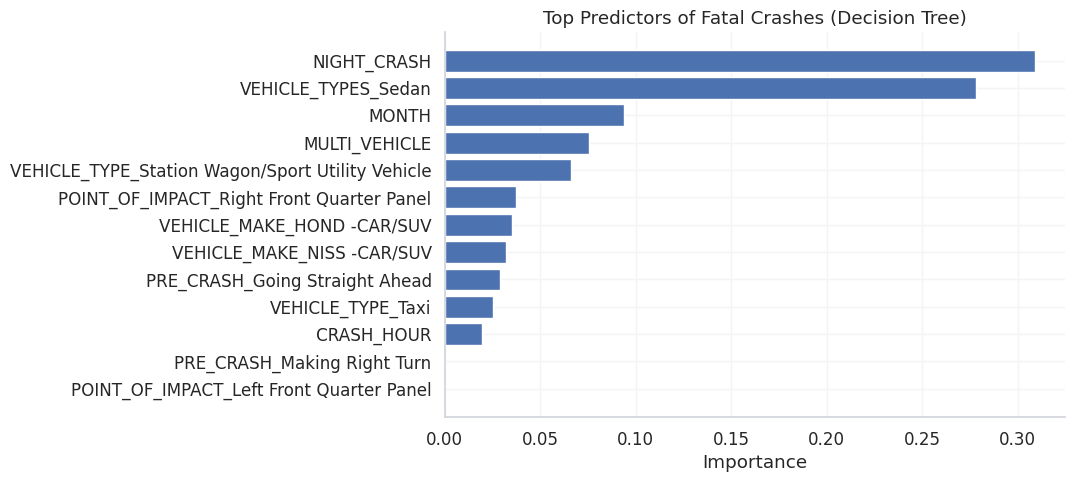

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.barh(importance.index, importance.values)
plt.gca().invert_yaxis()
plt.title("Top Predictors of Fatal Crashes (Decision Tree)")
plt.xlabel("Importance")
plt.show()

In [ ]:
print(len(importance))        # should be > 0
print(importance.sum())

13
1.0


In [ ]:
print(tree.feature_importances_)

[0.         0.         0.         ... 0.         0.         0.27794518]


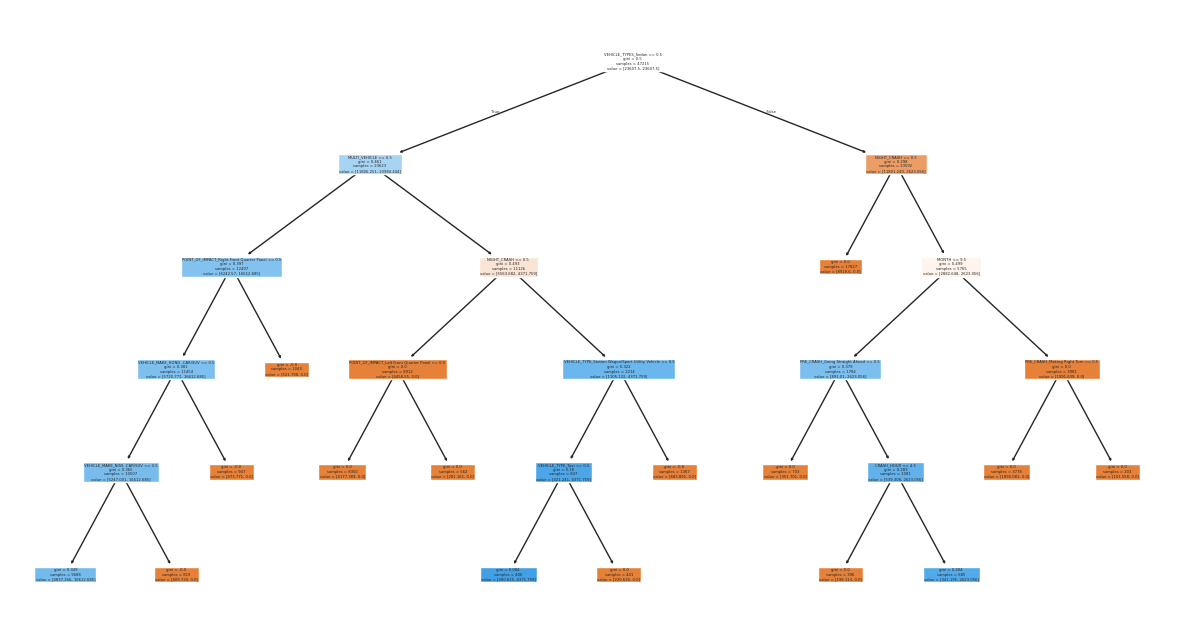

In [ ]:
# Visualizing Tree
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15,8))
plot_tree(tree, feature_names=X.columns, filled=True)
plt.show()

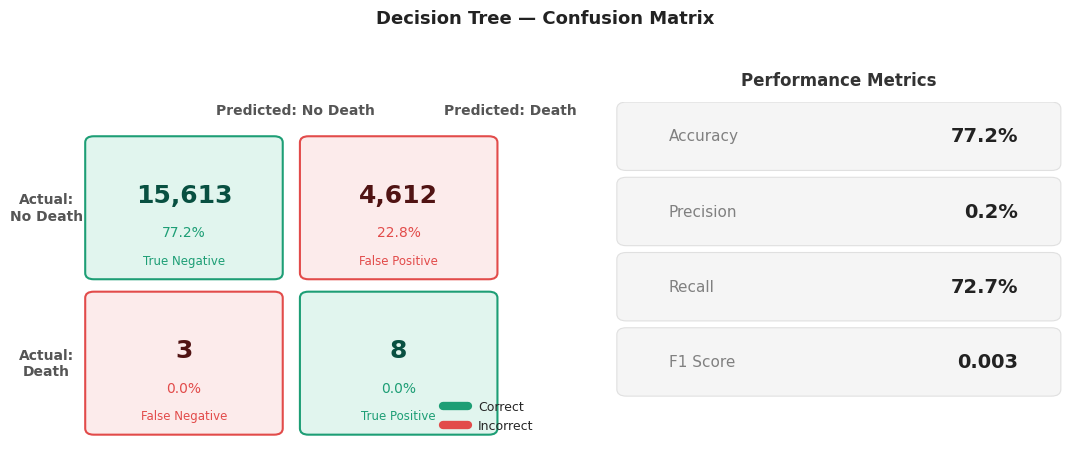

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

y_pred = tree.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
total = cm.sum()

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec  = recall_score(y_test, y_pred, zero_division=0)
f1   = f1_score(y_test, y_pred, zero_division=0)

GREEN_FILL, GREEN_EDGE, GREEN_TEXT = "#E1F5EE", "#1D9E75", "#085041"
RED_FILL,   RED_EDGE,   RED_TEXT   = "#FCEBEB", "#E24B4A", "#501313"

cells = [
    (0.05, 0.55, tn, GREEN_FILL, GREEN_EDGE, GREEN_TEXT, "True Negative"),
    (0.55, 0.55, fp,  RED_FILL,   RED_EDGE,   RED_TEXT, "False Positive"),
    (0.05, 0.05, fn,  RED_FILL,   RED_EDGE,   RED_TEXT, "False Negative"),
    (0.55, 0.05, tp, GREEN_FILL, GREEN_EDGE, GREEN_TEXT, "True Positive"),
]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5),
                         gridspec_kw={"width_ratios": [1, 1]})

# ── Left: matrix ──────────────────────────────────────────────────────
ax = axes[0]
ax.set_xlim(0, 1.1)
ax.set_ylim(0, 1.1)
ax.axis("off")

for (x, y, val, fc, ec, tc, label) in cells:
    ax.add_patch(mpatches.FancyBboxPatch(
        (x, y), 0.42, 0.42,
        boxstyle="round,pad=0.02",
        facecolor=fc, edgecolor=ec, linewidth=1.5,
        transform=ax.transData
    ))
    ax.text(x + 0.21, y + 0.25, f"{val:,}",
            ha="center", va="center",
            fontsize=18, fontweight="bold", color=tc)
    ax.text(x + 0.21, y + 0.13, f"{val/total:.1%}",
            ha="center", va="center",
            fontsize=10, color=ec)
    ax.text(x + 0.21, y + 0.04, label,
            ha="center", va="center",
            fontsize=8.5, color=ec)

# Axis labels
ax.text(0.52, 1.06, "Predicted: No Death", ha="center", fontsize=10,
        fontweight="bold", color="#555", transform=ax.transData)
ax.text(1.02, 1.06, "Predicted: Death",    ha="center", fontsize=10,
        fontweight="bold", color="#555", transform=ax.transData)
ax.text(-0.06, 0.76, "Actual:\nNo Death",  ha="center", va="center",
        fontsize=10, fontweight="bold", color="#555", transform=ax.transData)
ax.text(-0.06, 0.26, "Actual:\nDeath",     ha="center", va="center",
        fontsize=10, fontweight="bold", color="#555", transform=ax.transData)

# Legend
for color, label in [(GREEN_EDGE, "Correct"), (RED_EDGE, "Incorrect")]:
    ax.plot([], [], color=color, linewidth=6, label=label, solid_capstyle="round")
ax.legend(loc="lower right", fontsize=9, frameon=False)

# ── Right: metrics ────────────────────────────────────────────────────
ax2 = axes[1]
ax2.axis("off")

metrics = [
    ("Accuracy",  f"{acc:.1%}"),
    ("Precision", f"{prec:.1%}"),
    ("Recall",    f"{rec:.1%}"),
    ("F1 Score",  f"{f1:.3f}"),
]

for k, (label, val) in enumerate(metrics):
    y_pos = 0.82 - k * 0.22
    ax2.add_patch(mpatches.FancyBboxPatch(
        (0.05, y_pos), 0.90, 0.16,
        boxstyle="round,pad=0.02",
        facecolor="#F5F5F5", edgecolor="#E0E0E0",
        linewidth=0.8, transform=ax2.transAxes
    ))
    ax2.text(0.14, y_pos + 0.08, label, transform=ax2.transAxes,
             fontsize=11, color="gray", va="center")
    ax2.text(0.88, y_pos + 0.08, val, transform=ax2.transAxes,
             fontsize=14, fontweight="bold", color="#222",
             ha="right", va="center")

ax2.set_title("Performance Metrics", fontsize=12,
              fontweight="bold", pad=12, color="#333")

plt.suptitle("Decision Tree — Confusion Matrix", fontsize=13,
             fontweight="bold", y=1.01, color="#222")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

* Recall measures the proportion of actual fatal crashes correctly identified by the model, while precision measures the proportion of predicted fatal crashes that are truly fatal. In our results, the model achieves relatively high recall but very low precision, reflecting the difficulty of predicting rare events such as fatalities. This imbalance highlights the limitations of predictive performance but does not affect the interpretation of variable importance.

# Comparison of Models

In [ ]:
# Creating a function to extract results from all models
results = []

def extract_result(name, result):
    coef = result.params.get('IS_FORD', None)
    pval = result.pvalues.get('IS_FORD', None)

    results.append({
        'Model': name,
        'Ford Coef': coef,
        'p-value': pval,
        'Significant': 'Yes' if pval < 0.05 else 'No'
    })

In [ ]:
# Calling function "extract result" on all model results
extract_result('Simple Model (Only Ford)', result)
extract_result('Multiple Regression Model', result2)
extract_result('Multiple Regression Model (DV: Injury)', injury_result)
extract_result('Subsample Male Only', result_male)
extract_result('Subsample Male Only (DV: Injury)', result_male_injury)
extract_result('Subsample Sedan Only', injury_result_sedan)
#extract_result('Subsample Sedan Only (DV: Death)', sedan_sample_result) --- I commented out because it was skewing the last plot
extract_result('Subsample SUV Only (DV: Death)', suv_sample_result)
extract_result('Subsample New Cars Only', result_new)
extract_result('Subsample Mid Cars Only', result_mid_cars)
extract_result('Subsample Old Cars Only', result_old_cars)

In [ ]:
# Creating a dataframe of the comparison table
comparison_table = pd.DataFrame(results)
print(comparison_table)

                                    Model  Ford Coef   p-value Significant
0                Simple Model (Only Ford)   0.844425  0.033916         Yes
1               Multiple Regression Model   0.608091  0.133255          No
2  Multiple Regression Model (DV: Injury)   0.018200  0.583108          No
3                     Subsample Male Only   0.470145  0.313019          No
4        Subsample Male Only (DV: Injury)   0.004481  0.904281          No
5                    Subsample Sedan Only   0.063532  0.264194          No
6          Subsample SUV Only (DV: Death)   0.390100  0.546632          No
7                 Subsample New Cars Only   0.701538  0.215651          No
8                 Subsample Mid Cars Only   0.940820  0.188502          No
9                 Subsample Old Cars Only  -0.207514  0.850566          No


# Comparison Table

In [ ]:
comparison_table['Ford Coef'] = comparison_table['Ford Coef'].round(3)
comparison_table['p-value'] = comparison_table['p-value'].round(3)
comparison_table

,Model,Ford Coef,p-value,Significant
0,Simple Model (Only Ford),0.844,0.034,Yes
1,Multiple Regression Model,0.608,0.133,No
2,Multiple Regression Model (DV: Injury),0.018,0.583,No
3,Subsample Male Only,0.470,0.313,No
4,Subsample Male Only (DV: Injury),0.004,0.904,No
5,Subsample Sedan Only,0.064,0.264,No
6,Subsample SUV Only (DV: Death),0.390,0.547,No
7,Subsample New Cars Only,0.702,0.216,No
8,Subsample Mid Cars Only,0.941,0.189,No
9,Subsample Old Cars Only,-0.208,0.851,No


# Pot of Comparison Table

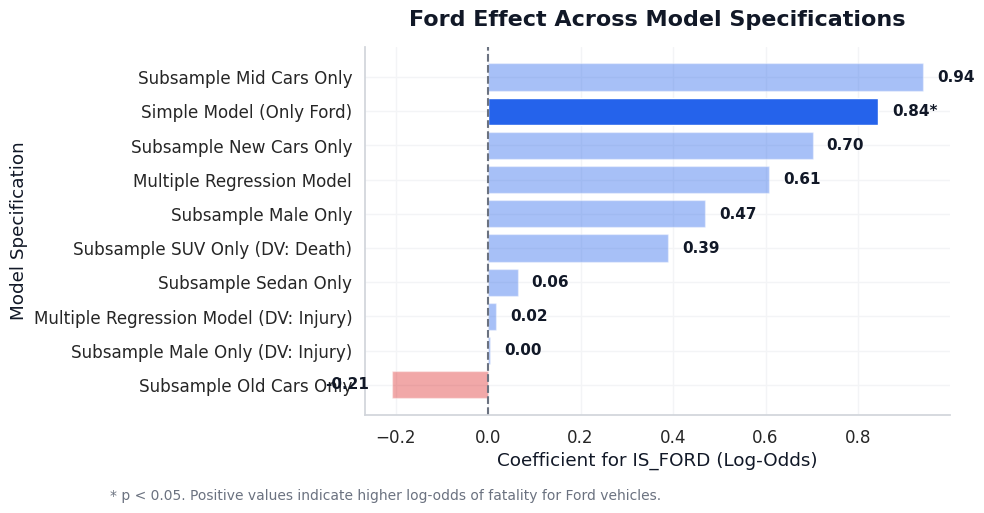

In [ ]:
# Sort by coefficient
comparison_table = comparison_table.sort_values("Ford Coef")

# Color logic
colors = comparison_table["Ford Coef"].apply(
    lambda x: BLUE if x > 0 else RED
)

# Significance marker
comparison_table["sig"] = comparison_table["p-value"].apply(
    lambda p: "*" if p < 0.05 else ""
)

plt.figure(figsize=(10, 5))

bars = plt.barh(
    comparison_table["Model"],
    comparison_table["Ford Coef"],
    color=colors
)
# Add transparency
alphas = comparison_table["p-value"].apply(lambda p: 1 if p < 0.05 else 0.4)

for bar, alpha in zip(bars, alphas):
    bar.set_alpha(alpha)

# Zero line
plt.axvline(0, color=GRAY, linestyle="--", linewidth=1.5)

# Labels
for i, row in comparison_table.iterrows():
    coef = row["Ford Coef"]
    sig = row["sig"]

    plt.text(
        coef + 0.03 if coef >= 0 else coef - 0.05,
        list(comparison_table.index).index(i),
        f"{coef:.2f}{sig}",
        va="center",
        ha="left" if coef >= 0 else "right",
        fontsize=11,
        color=DARK_TEXT,
        fontweight="bold"
    )

plt.title(
    "Ford Effect Across Model Specifications",
    fontsize=16,
    fontweight="bold",
    color=DARK_TEXT,
    pad=15
)

plt.xlabel("Coefficient for IS_FORD (Log-Odds)", color=DARK_TEXT)
plt.ylabel("Model Specification", color=DARK_TEXT)

plt.figtext(
    0.12, -0.02,
    "* p < 0.05. Positive values indicate higher log-odds of fatality for Ford vehicles.",
    fontsize=10,
    color=GRAY
)

plt.tight_layout()
plt.show()